# 03 - EDA and Preprocessing


In [1]:
!uv pip install huggingface_hub webdataset librosa soundfile xgboost statsmodels pyarrow fastparquet

Using Python 3.12.3 environment at: /home/desan/Hackathons/codefest/.venv
Checked 8 packages in 25ms


In [2]:
# ── Section 0-B: imports ──────────────────────────────────────────────────────
import tarfile
import sys, os, re, json, io, time, logging, warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import scipy.signal as ss
import scipy.stats as st
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import soundfile as sf

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve,
)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import mutual_info_classif

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("[WARN] XGBoost not available; falling back to HistGradientBoostingClassifier")

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

import webdataset as wds
from huggingface_hub import hf_hub_download, list_repo_files, snapshot_download

import joblib

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

print(f"Python  : {sys.version}")
print(f"NumPy   : {np.__version__}")
print(f"Pandas  : {pd.__version__}")
print(f"librosa : {librosa.__version__}")
print(f"sklearn : {__import__('sklearn').__version__}")
if HAS_XGB:
    print(f"xgboost : {xgb.__version__}")

Python  : 3.12.3 (main, Jun 19 2026, 12:46:00) [GCC 13.3.0]
NumPy   : 2.5.3
Pandas  : 3.0.5
librosa : 1.0.0
sklearn : 1.9.0
xgboost : 3.4.1


In [3]:
# ── Section 0-C: global configuration ────────────────────────────────────────
# All tuneable parameters in one place.

RANDOM_SEED   = 42
np.random.seed(RANDOM_SEED)

# Dataset
HF_REPO       = "DesanSilva/sscc-compact-av"
HF_REPO_TYPE  = "dataset"
DATA_DIR      = Path("data/sscc_compact")
OUT_DIR       = Path("outputs")

# Signal parameters (from SSCC spec)
VIB_RATE_HZ       = 100_000     # original acquisition rate
VIB_STORED_HZ     = 10_000      # stored/downsampled rate (compact set)
AUD_RATE_HZ       = 44_100      # recorder (Zoom H5) rate
CLIP_DURATION_S   = 5.0
N_VIB_CHANNELS    = 4

# Feature extraction windows
WINDOW_SIZE_S = 1.0
HOP_SIZE_S    = 0.5

# Vibration frequency bands (Hz) - physically motivated for chain conveyor
VIB_BANDS = {
    "low":    (0,    500),
    "mid":    (500,  2000),
    "high":   (2000, 5000),
}

# Audio frequency bands (Hz)
AUD_BANDS = {
    "sub":    (0,    200),
    "low":    (200,  1000),
    "mid":    (1000, 4000),
    "high":   (4000, 8000),
    "air":    (8000, 16000),
}

# Envelope analysis bandpass (Hz) - mechanical fault region
ENV_BANDPASS_HZ = (500, 4000)

# MFCC
N_MFCC = 13

# Temporal smoothing
EMA_ALPHA     = 0.4
MAVG_WINDOW   = 3
NOM_N         = 3
NOM_M         = 5
PERSIST_K     = 3

# Split sizes
VALID_FRAC = 0.15
TEST_FRAC  = 0.15

# XGBoost / fallback
XGB_ROUNDS        = 500
XGB_EARLY_STOP    = 30
XGB_N_FOLDS       = 5

# Output subdirectories
for sub in ["eda", "features", "models", "metrics", "reports"]:
    (OUT_DIR / sub).mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[logging.StreamHandler()]
)
log = logging.getLogger("sscc_poc")

# Plotting defaults
matplotlib.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})
PALETTE = {"normal": "#2ecc71", "dry": "#e74c3c", "lean": "#e67e22",
           "loose": "#9b59b6", "screwdrop": "#3498db"}

print("Configuration complete.")

Configuration complete.


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
# Use a clean, professional plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("muted")

In [5]:
import pandas as pd
import joblib
meta_df = pd.read_parquet(OUT_DIR / '02_prep_state.parquet')
audit_df = pd.read_parquet(OUT_DIR / '02_audit_state.parquet')
raw_inventory = joblib.load(OUT_DIR / '02_raw_inventory.pkl')
SHARD_CACHE = DATA_DIR / 'shards'
complete_ids = [sid for sid, rec in raw_inventory.items() if {'vib', 'audio'} <= set(rec['modalities'])]
print('Loaded metadata with shape:', meta_df.shape)


Loaded metadata with shape: (288, 36)


### Loaded Helper Functions


In [6]:
# ── Section 1-A: file-level patterns ─────────────────────────────────────────

FRAME_PATTERN = re.compile(
    r"^(?P<sample_id>.+)\.(?P<device>ios|android)\.frame_(?P<index>\d{2})\.webp$"
)
BASE_SUFFIXES = {
    ".audio.flac": "audio",
    ".vib.npz":    "vibration",
    ".json":       "metadata",
}

def _parse_member_key(key: str) -> Tuple[Optional[str], Optional[str], Optional[str]]:
    """Return (sample_id, modality, extra) for a WebDataset member key.

    extra is None for base members, device string for frame members.
    Returns (None, None, None) if the key does not match known patterns.
    """
    m = FRAME_PATTERN.match(key)
    if m:
        return m.group("sample_id"), "video_frame", m.group("device")
    for suffix, modality in BASE_SUFFIXES.items():
        if key.endswith(suffix):
            sample_id = key[: -len(suffix)]
            return sample_id, modality, None
    return None, None, None


def _decode_vib(raw: bytes) -> np.ndarray:
    """Decode vibration .npz bytes → float32 array, shape (4, T)."""
    buf = io.BytesIO(raw)
    npz = np.load(buf, allow_pickle=False)
    # Accept either key 'data' or the first key
    key = "data" if "data" in npz else list(npz.keys())[0]
    arr = npz[key].astype(np.float32)
    if arr.ndim == 1:
        arr = arr[np.newaxis, :]  # single-channel fallback
    return arr


def _decode_audio(raw: bytes) -> Tuple[np.ndarray, int]:
    """Decode audio .flac bytes → (float32 mono array, sample_rate)."""
    buf = io.BytesIO(raw)
    wav, sr = sf.read(buf, dtype="float32", always_2d=False)
    if wav.ndim == 2:  # stereo → mono
        wav = wav.mean(axis=1)
    return wav, sr


def _decode_meta(raw: bytes) -> dict:
    """Decode JSON bytes → dict."""
    return json.loads(raw.decode("utf-8"))


print("Shard loading helpers defined.")

Shard loading helpers defined.


In [7]:
def _shard_path_for(sample_id: str) -> Path:
    return SHARD_CACHE / f"shard_{raw_inventory[sample_id]['shard_idx']:04d}.tar"


In [8]:
# ── Section 5-A: signal loaders ───────────────────────────────────────────────

def load_vibration(sample_id: str) -> np.ndarray:
    """Load 4-channel vibration array from shard. Returns shape (4, T)."""
    shard_path = _shard_path_for(sample_id)
    key = f"{sample_id}.vib.npz"
    with tarfile.open(shard_path, "r:") as tf:
        raw = tf.extractfile(tf.getmember(key)).read()
    return _decode_vib(raw)


def load_audio(sample_id: str) -> Tuple[np.ndarray, int]:
    """Load recorder audio from shard. Returns (float32 mono, sample_rate)."""
    shard_path = _shard_path_for(sample_id)
    key = f"{sample_id}.audio.flac"
    with tarfile.open(shard_path, "r:") as tf:
        raw = tf.extractfile(tf.getmember(key)).read()
    return _decode_audio(raw)


def validate_vib(arr: np.ndarray, sample_id: str) -> bool:
    """Basic shape and finiteness checks for a vibration array."""
    expected_len = int(VIB_STORED_HZ * CLIP_DURATION_S)
    if arr.ndim != 2:
        log.error("%s: vib ndim=%d, expected 2", sample_id, arr.ndim)
        return False
    if arr.shape[0] < 1 or arr.shape[0] > 8:
        log.error("%s: vib channels=%d unexpected", sample_id, arr.shape[0])
        return False
    if arr.shape[1] < expected_len * 0.8:
        log.error("%s: vib length=%d too short (expected ~%d)", sample_id, arr.shape[1], expected_len)
        return False
    if not np.isfinite(arr).all():
        log.error("%s: vib contains non-finite values", sample_id)
        return False
    return True


def validate_audio(wav: np.ndarray, sr: int, sample_id: str) -> bool:
    """Basic checks for an audio array."""
    expected_len = int(sr * CLIP_DURATION_S)
    if wav.ndim != 1:
        log.error("%s: audio ndim=%d, expected 1 (mono)", sample_id, wav.ndim)
        return False
    if len(wav) < expected_len * 0.8:
        log.error("%s: audio length=%d too short", sample_id, len(wav))
        return False
    if not np.isfinite(wav).all():
        log.error("%s: audio non-finite", sample_id)
        return False
    return True


print("Signal loaders defined.")

Signal loaders defined.


---
# 1. Raw Vibration EDA

We load representative samples for each fault type and velocity, examining time domain, PSD, spectrogram, and envelope spectrum. Envelope analysis is physically motivated: mechanical faults (loose chain, screwdrop, lubrication issues) often produce amplitude-modulated vibration signatures that are revealed by envelope demodulation - amplitude modulation at a fault frequency that may not be visible in the raw PSD.

In [9]:
# ── Section 6-A: pick representative samples ──────────────────────────────────

FAULT_TYPES = ["normal", "dry", "lean", "loose", "screwdrop"]

def _pick_representative(fault, n=1):
    """Return up to n sample_ids for the given fault type."""
    subset = meta_df[meta_df["fault"] == fault]["sample_id"].tolist()
    rng = np.random.default_rng(RANDOM_SEED)
    chosen = rng.choice(subset, size=min(n, len(subset)), replace=False).tolist()
    return chosen

repr_samples = {f: _pick_representative(f, n=1)[0] for f in FAULT_TYPES if len(_pick_representative(f)) > 0}
print("Representative samples:")
for ft, sid in repr_samples.items():
    row = meta_df[meta_df["sample_id"] == sid].iloc[0]
    print(f"  {ft:12s} → {sid}  (vel={row.get('velocity', '?')})")

Representative samples:
  normal       → normal__med_vel100_clean__0018  (vel=100)
  dry          → abnormal__dry__med_vel100_clean_dry__0025  (vel=100)
  lean         → abnormal__lean__med_vel100_clean_lean__0022  (vel=100)
  loose        → abnormal__loose__med_vel100_clean_loose__0037  (vel=100)
  screwdrop    → abnormal__screwdrop__med_vel100_clean_screwdrop__0033  (vel=100)


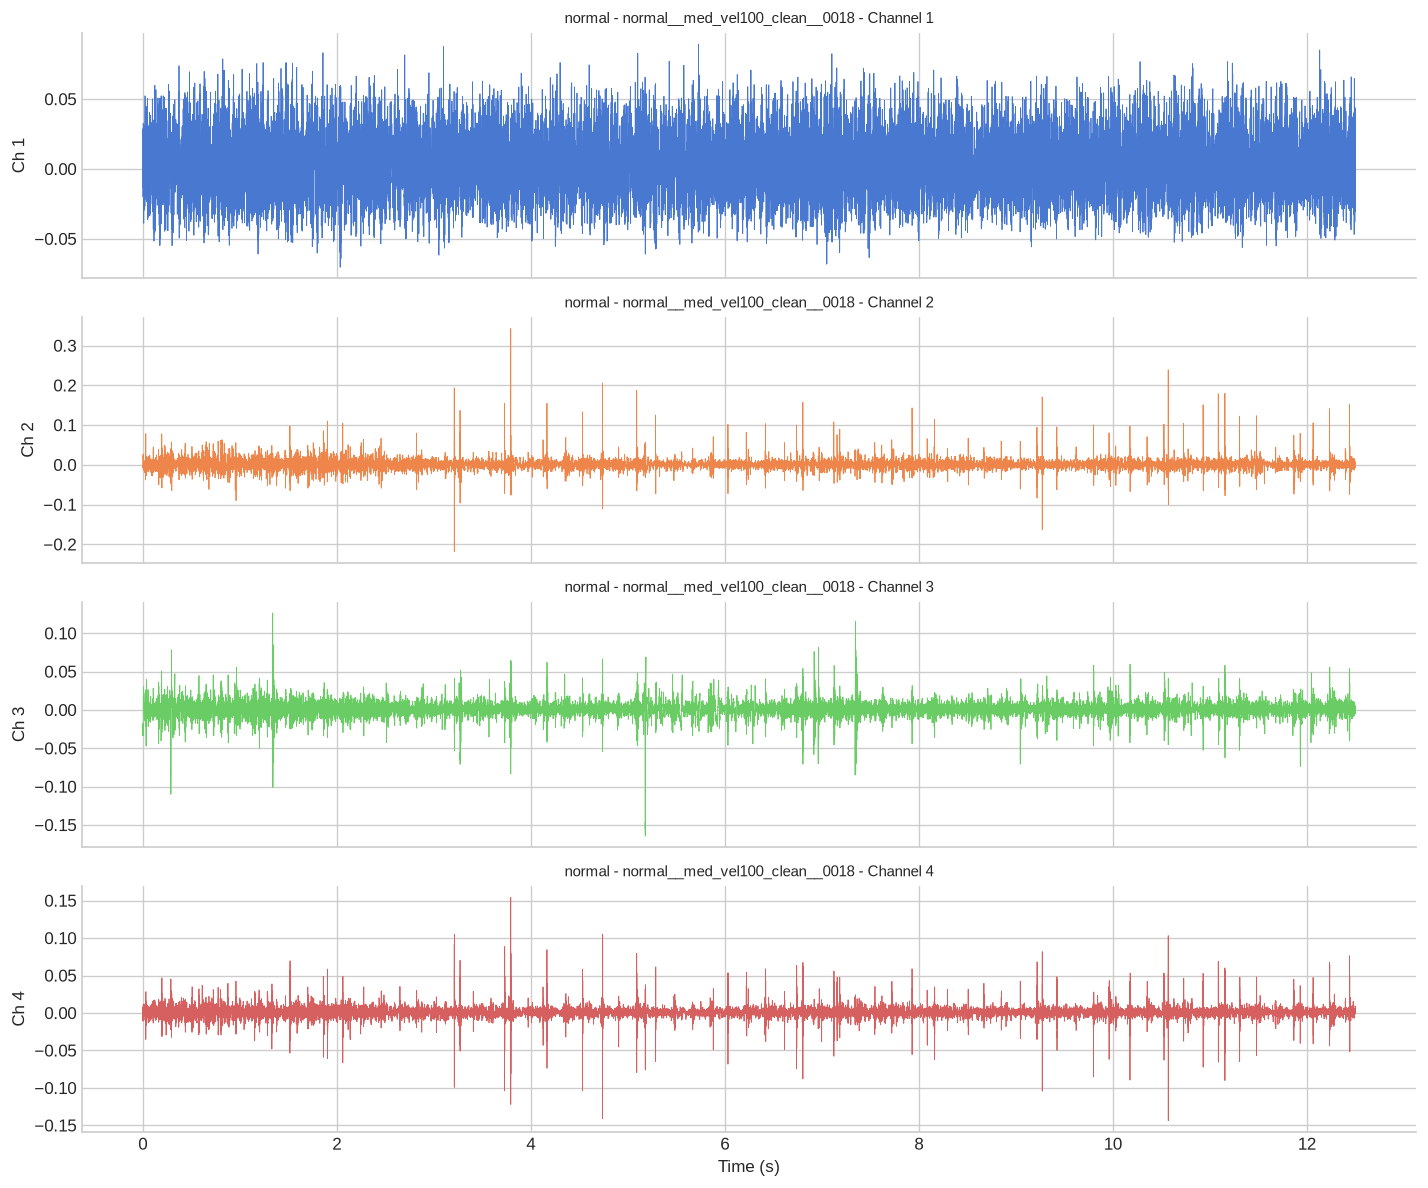

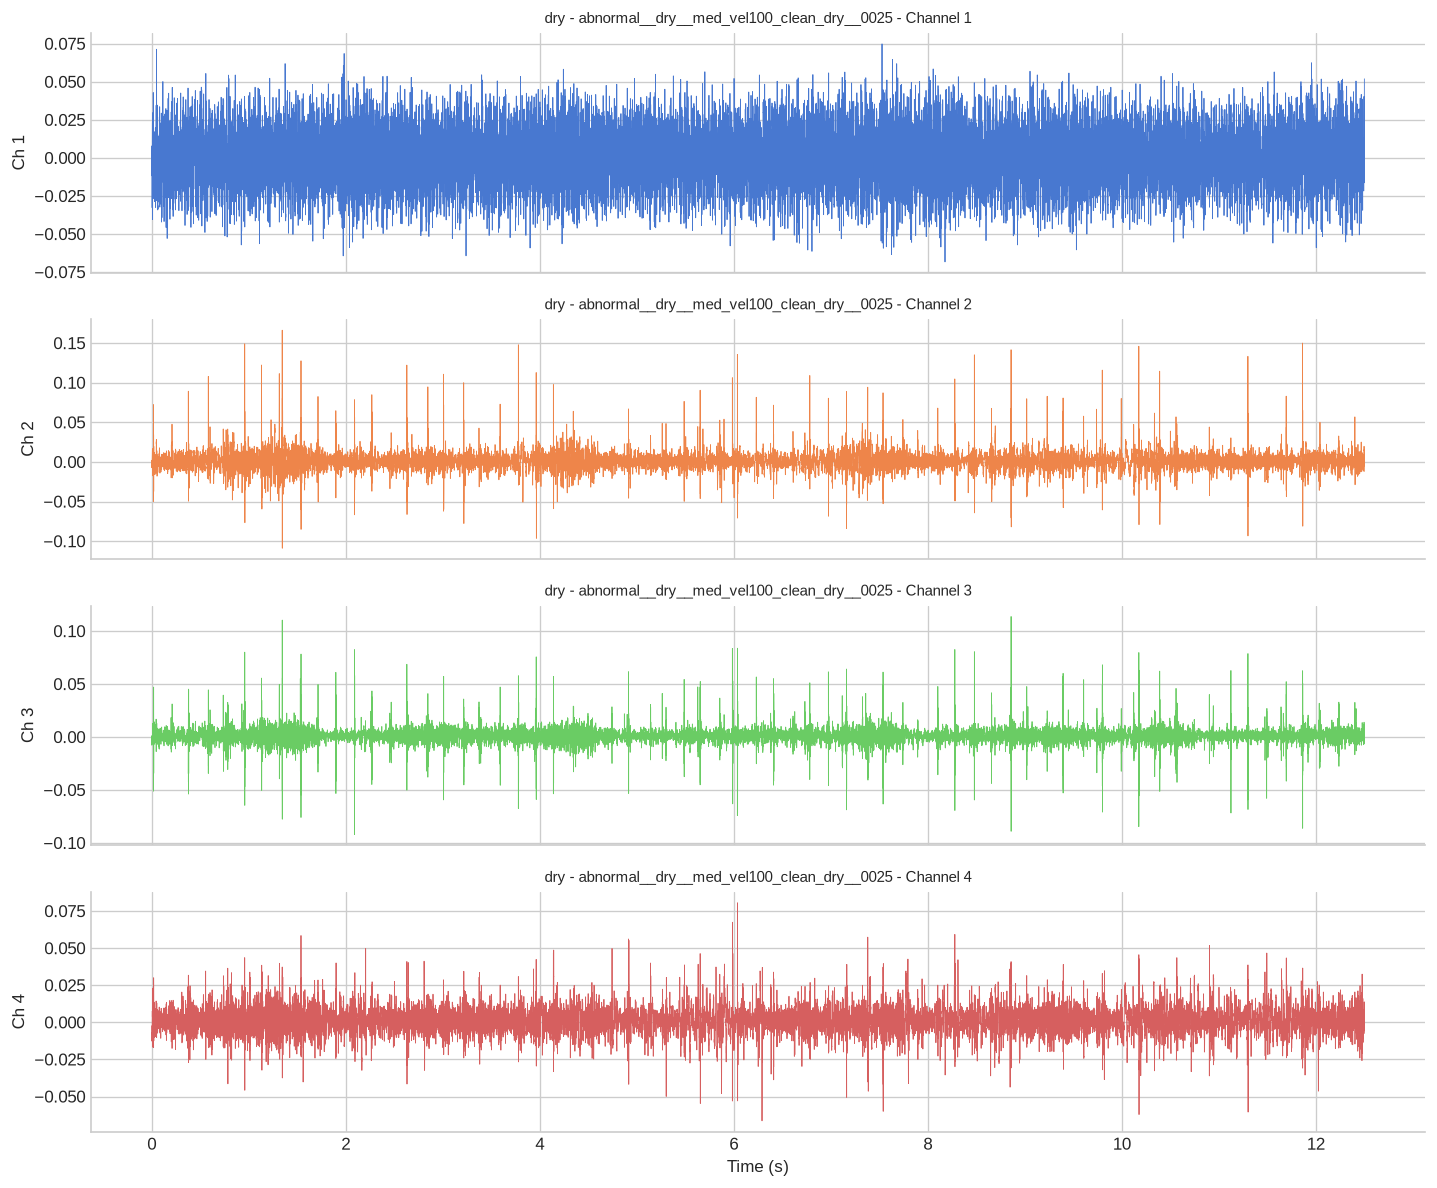

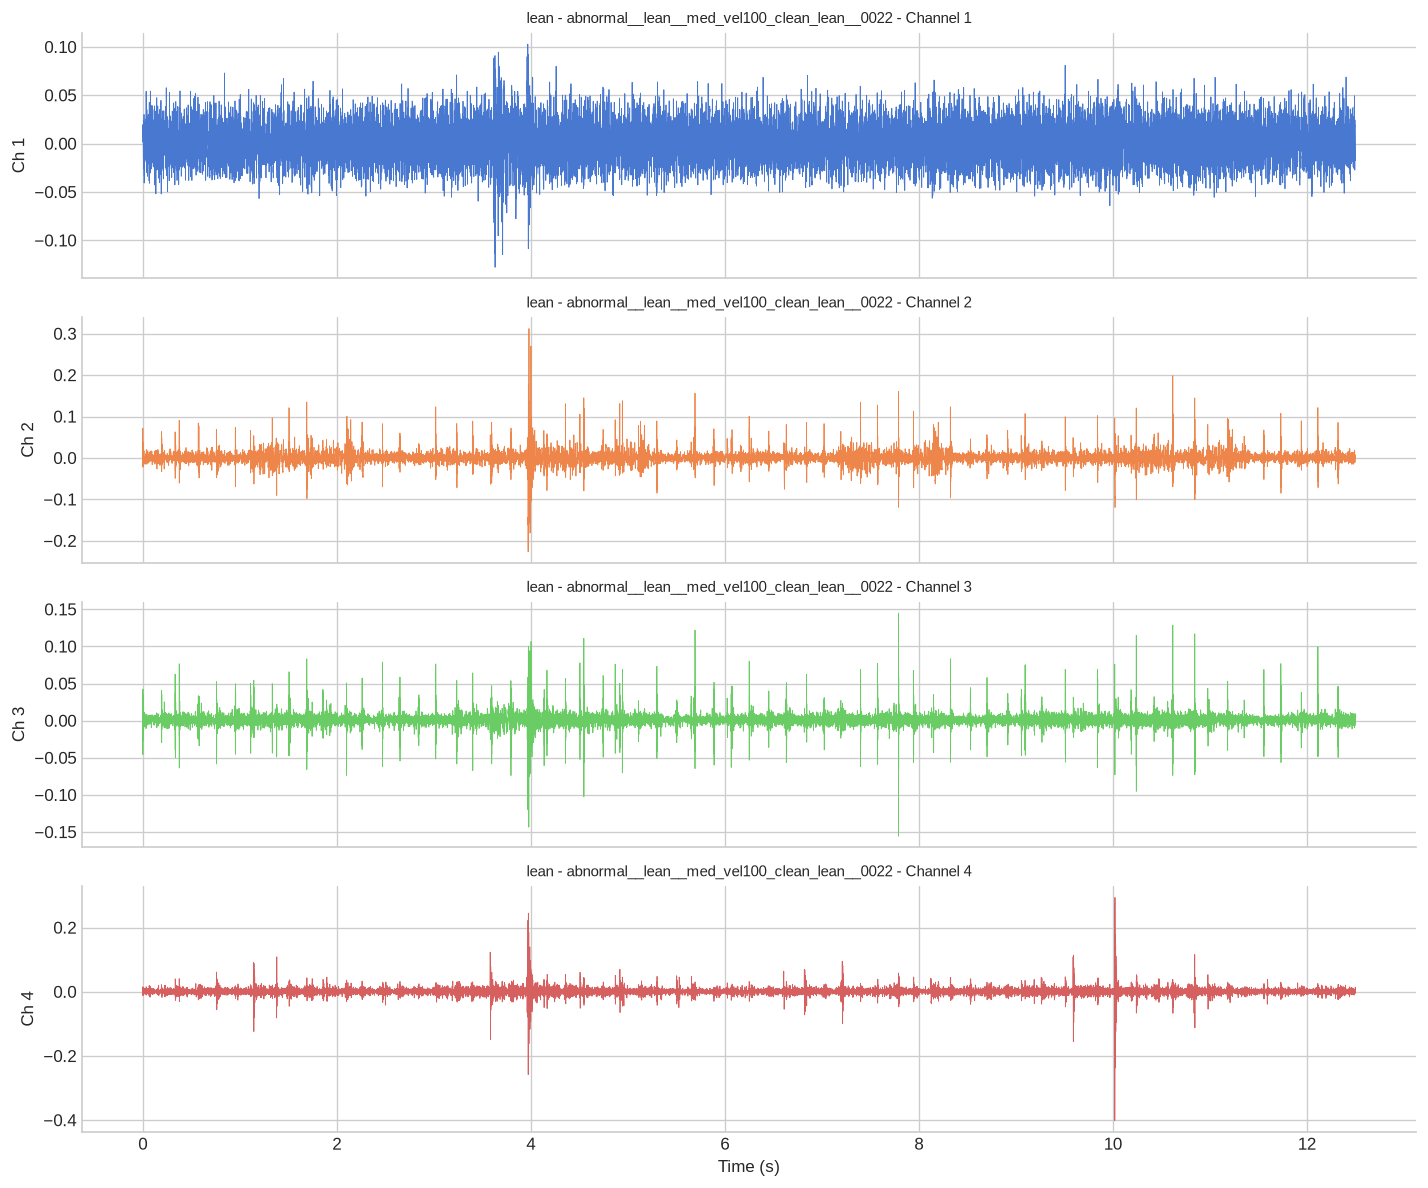

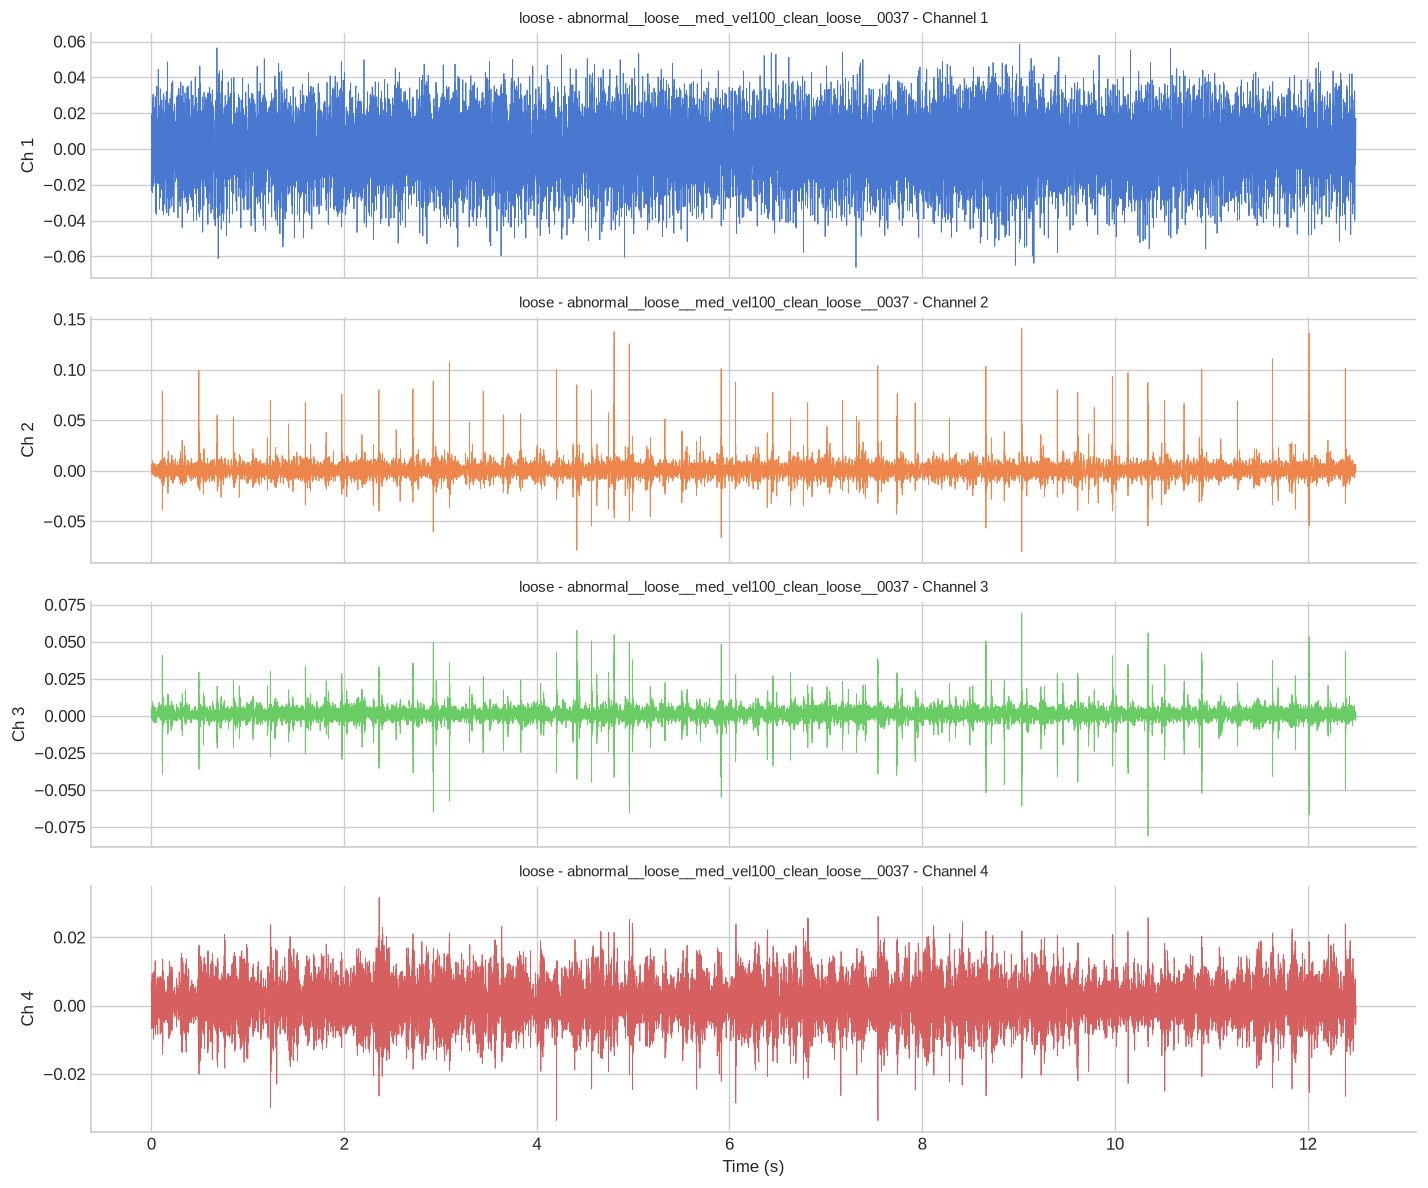

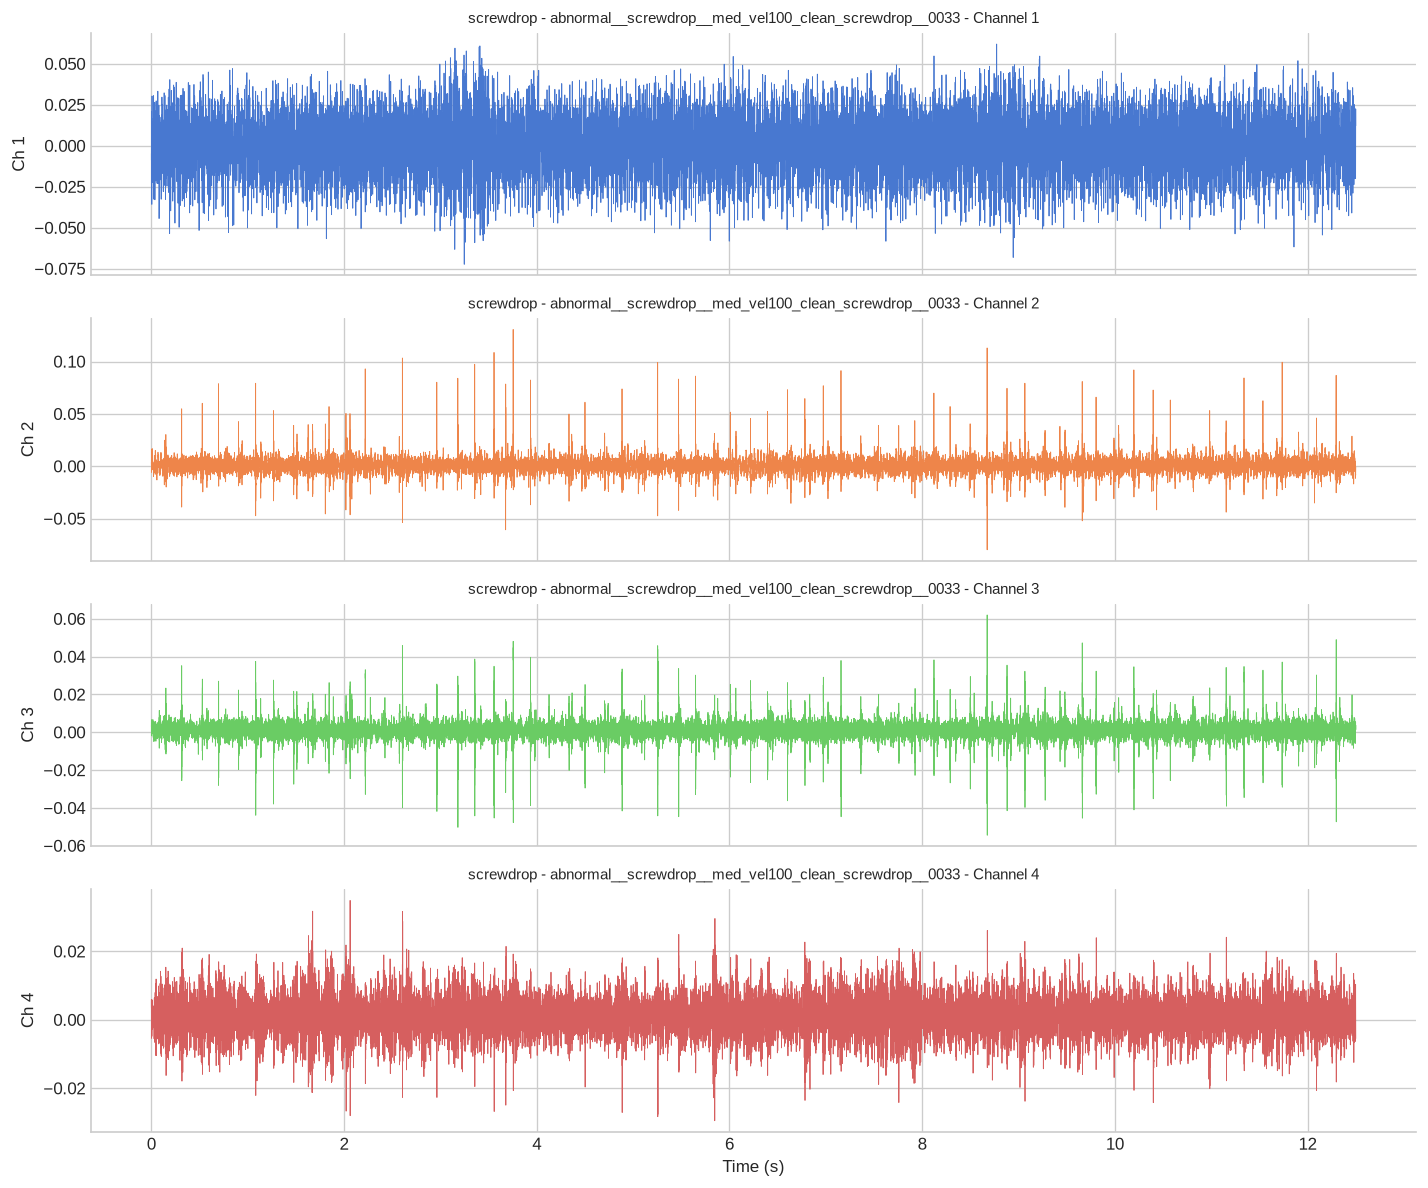

In [10]:
# ── Section 6-B: time-domain plots ────────────────────────────────────────────

def plot_vib_time(sample_id: str, fault: str) -> None:
    vib = load_vibration(sample_id)
    if not validate_vib(vib, sample_id):
        print(f"[SKIP] {sample_id} failed validation")
        return
    n_ch = vib.shape[0]
    t = np.arange(vib.shape[1]) / VIB_STORED_HZ
    fig, axes = plt.subplots(n_ch, 1, figsize=(12, 2.5 * n_ch), sharex=True)
    if n_ch == 1: axes = [axes]
    for ch, ax in enumerate(axes):
        ax.plot(t, vib[ch], lw=0.5, color=f"C{ch}")
        ax.set_ylabel(f"Ch {ch+1}")
        ax.set_title(f"{fault} - {sample_id} - Channel {ch+1}", fontsize=9)
    axes[-1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "eda" / f"vibration_time_{fault}.png", bbox_inches="tight")
    plt.show()

for fault, sid in repr_samples.items():
    plot_vib_time(sid, fault)

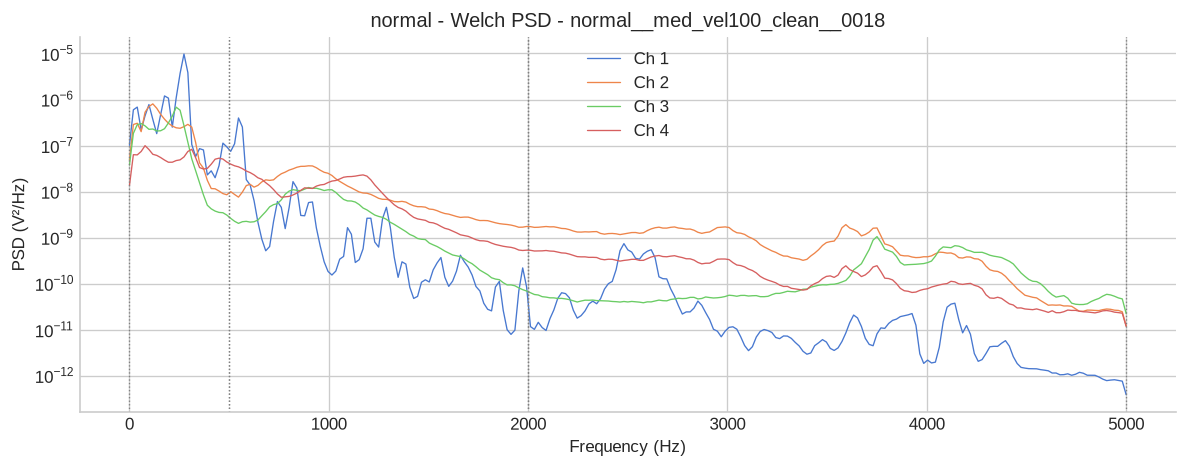

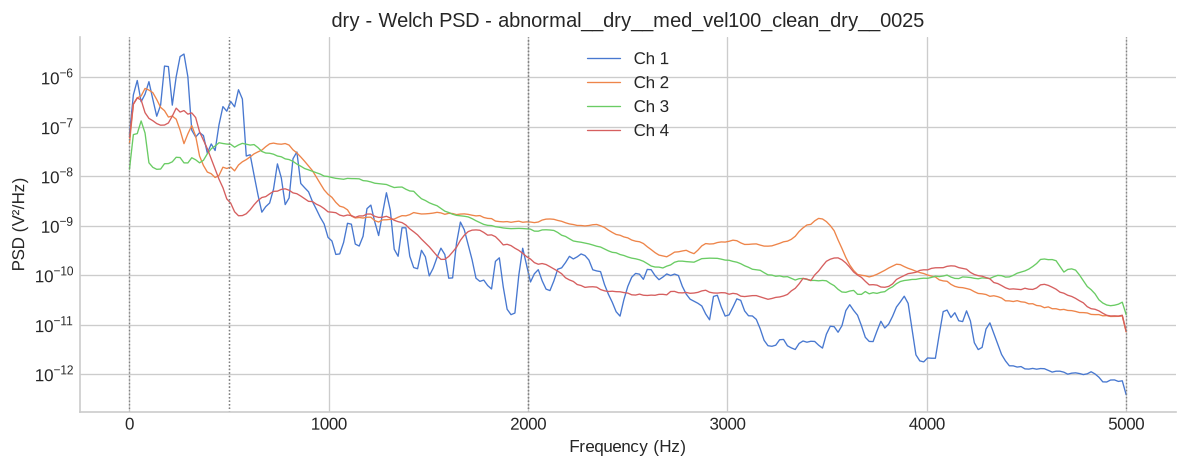

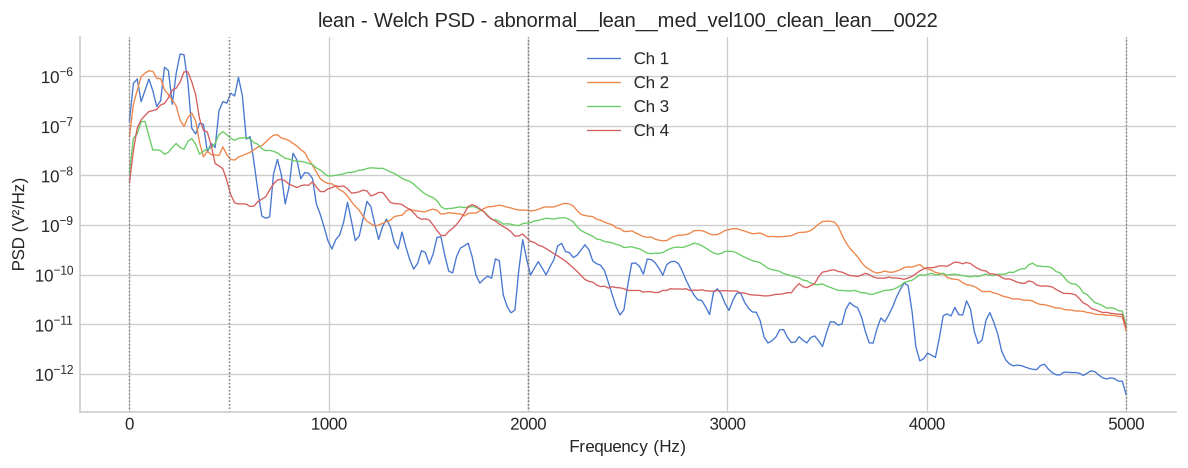

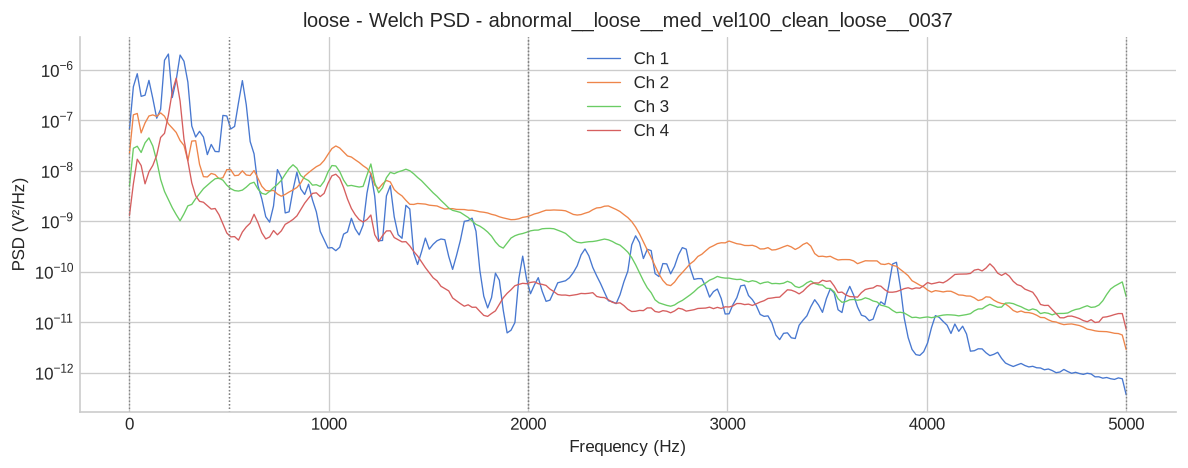

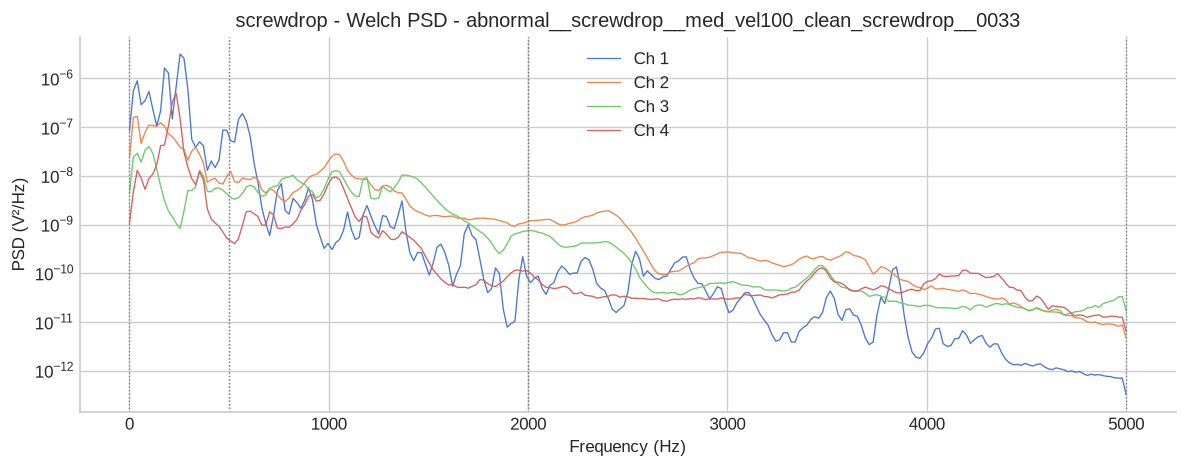

In [11]:
# ── Section 6-C: Welch PSD ────────────────────────────────────────────────────

def plot_vib_psd(sample_id: str, fault: str) -> None:
    vib = load_vibration(sample_id)
    if not validate_vib(vib, sample_id):
        return
    n_ch = vib.shape[0]
    fig, ax = plt.subplots(figsize=(10, 4))
    for ch in range(n_ch):
        f, pxx = ss.welch(vib[ch], fs=VIB_STORED_HZ, nperseg=512)
        ax.semilogy(f, pxx, lw=0.8, label=f"Ch {ch+1}")
    # Mark band boundaries
    for band, (lo, hi) in VIB_BANDS.items():
        ax.axvline(lo, ls=":", lw=0.8, color="grey")
        ax.axvline(hi, ls=":", lw=0.8, color="grey")
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("PSD (V²/Hz)")
    ax.set_title(f"{fault} - Welch PSD - {sample_id}")
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / "eda" / f"vibration_psd_{fault}.png", bbox_inches="tight")
    plt.show()

for fault, sid in repr_samples.items():
    plot_vib_psd(sid, fault)

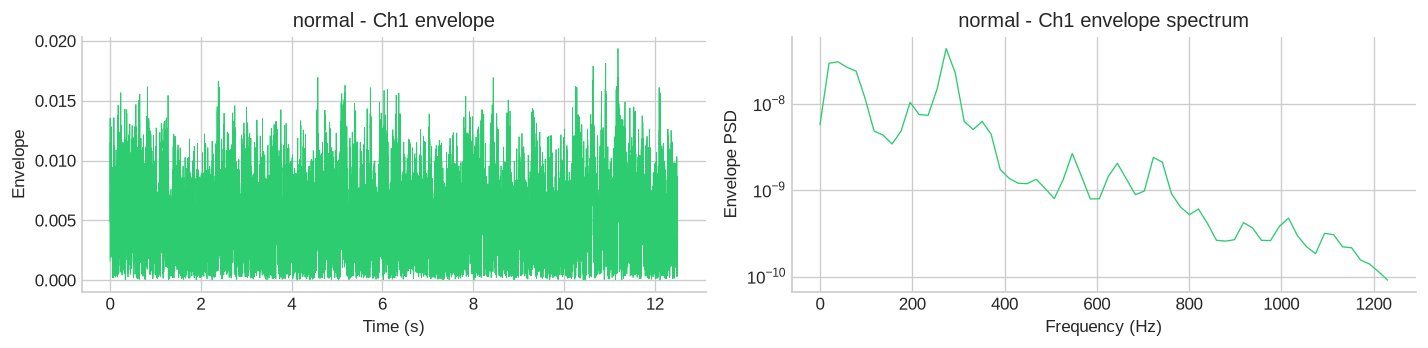

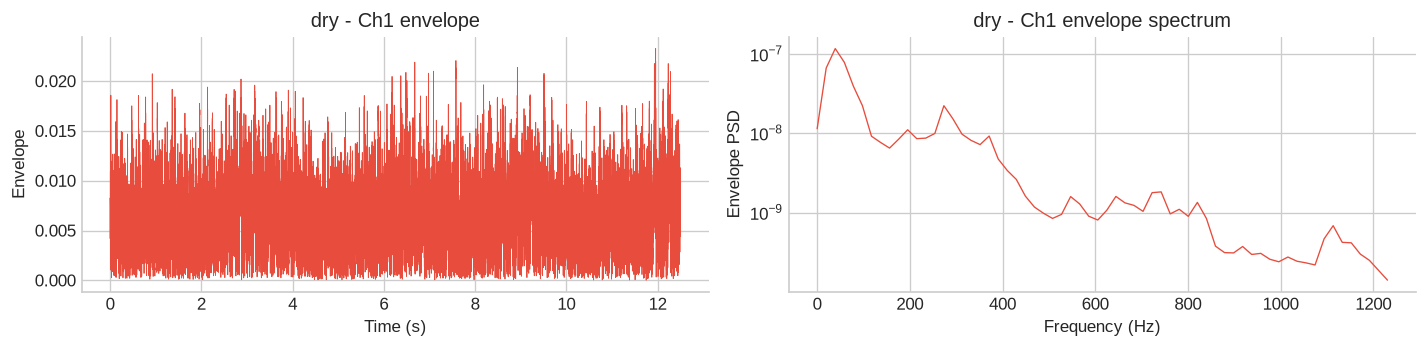

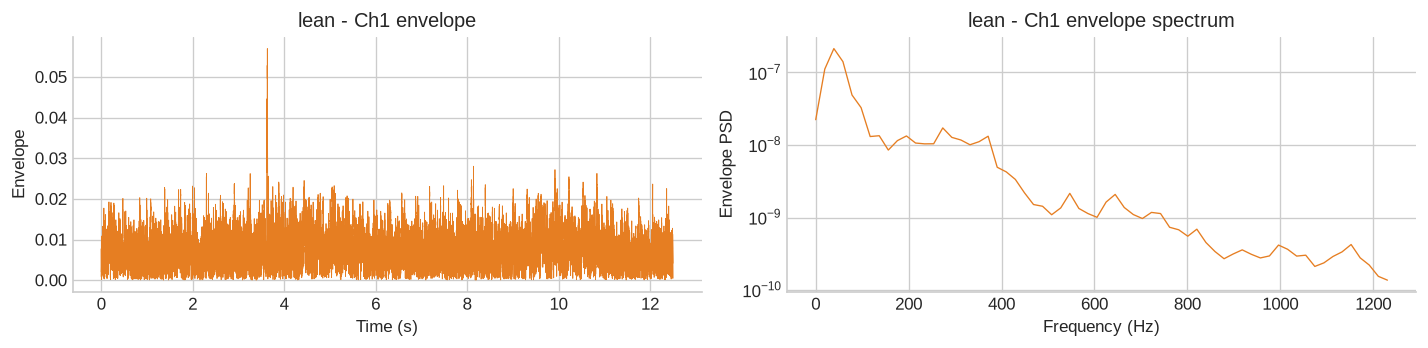

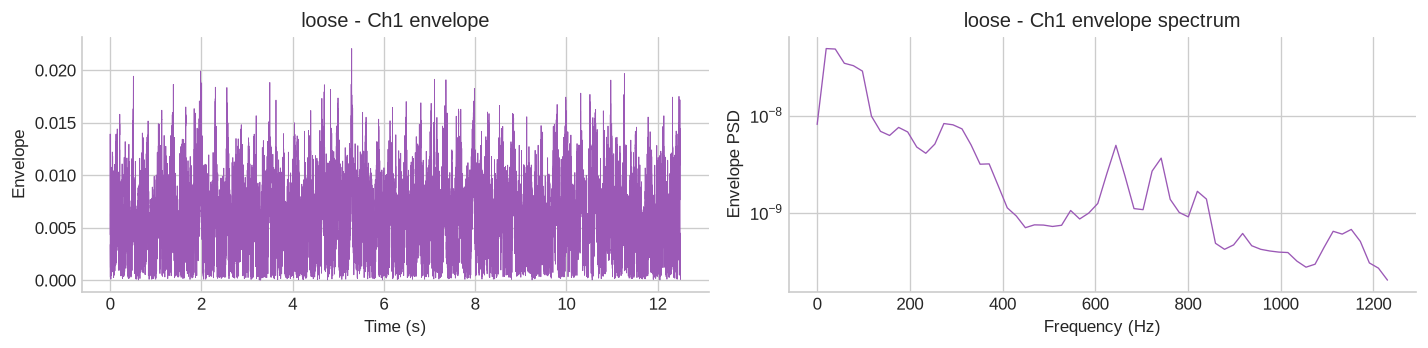

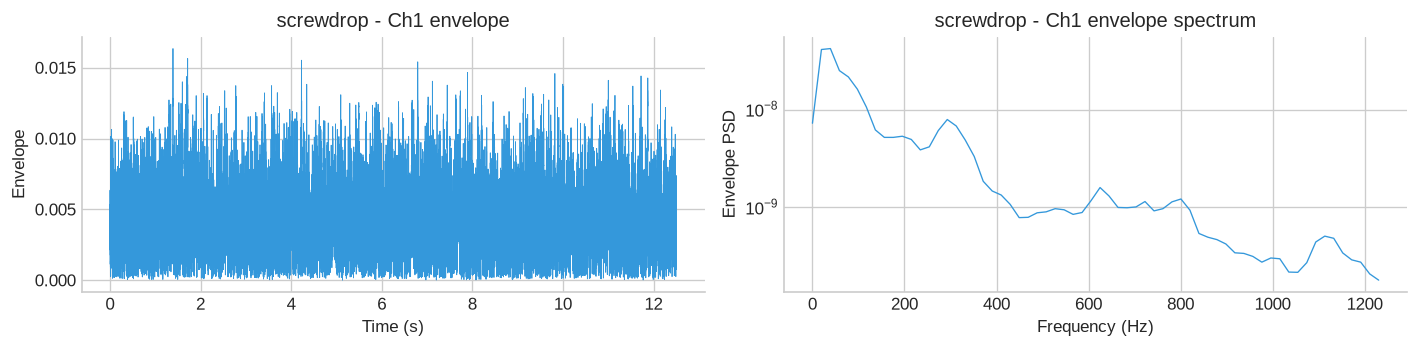

In [12]:
# ── Section 6-D: envelope analysis ────────────────────────────────────────────
# Rationale: chain conveyor faults (especially 'loose' and 'screwdrop') produce
# impulsive, amplitude-modulated vibration. The envelope spectrum reveals
# modulation frequencies that are hidden in the carrier PSD.
# Steps: bandpass → Hilbert → envelope → PSD of envelope.

def _envelope(sig: np.ndarray, fs: int,
              lo: float = ENV_BANDPASS_HZ[0],
              hi: float = ENV_BANDPASS_HZ[1]) -> np.ndarray:
    """Bandpass → Hilbert envelope."""
    nyq = fs / 2.0
    lo_n, hi_n = lo / nyq, hi / nyq
    if hi_n >= 1.0:
        hi_n = 0.999
    sos = ss.butter(4, [lo_n, hi_n], btype="bandpass", output="sos")
    filtered = ss.sosfilt(sos, sig)
    analytic = ss.hilbert(filtered)
    return np.abs(analytic)


def plot_envelope_spectrum(sample_id: str, fault: str, ch: int = 0) -> None:
    vib = load_vibration(sample_id)
    if not validate_vib(vib, sample_id):
        return
    env = _envelope(vib[ch], VIB_STORED_HZ)
    f, pxx = ss.welch(env, fs=VIB_STORED_HZ, nperseg=512)
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))
    t = np.arange(len(env)) / VIB_STORED_HZ
    axes[0].plot(t, env, lw=0.5, color=PALETTE.get(fault, "C0"))
    axes[0].set_xlabel("Time (s)"); axes[0].set_ylabel("Envelope")
    axes[0].set_title(f"{fault} - Ch{ch+1} envelope")
    axes[1].semilogy(f[:len(f)//4], pxx[:len(f)//4], lw=0.8, color=PALETTE.get(fault, "C0"))
    axes[1].set_xlabel("Frequency (Hz)"); axes[1].set_ylabel("Envelope PSD")
    axes[1].set_title(f"{fault} - Ch{ch+1} envelope spectrum")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "eda" / f"vibration_envelope_{fault}.png", bbox_inches="tight")
    plt.show()

for fault, sid in repr_samples.items():
    plot_envelope_spectrum(sid, fault)

---
# 2. Audio EDA


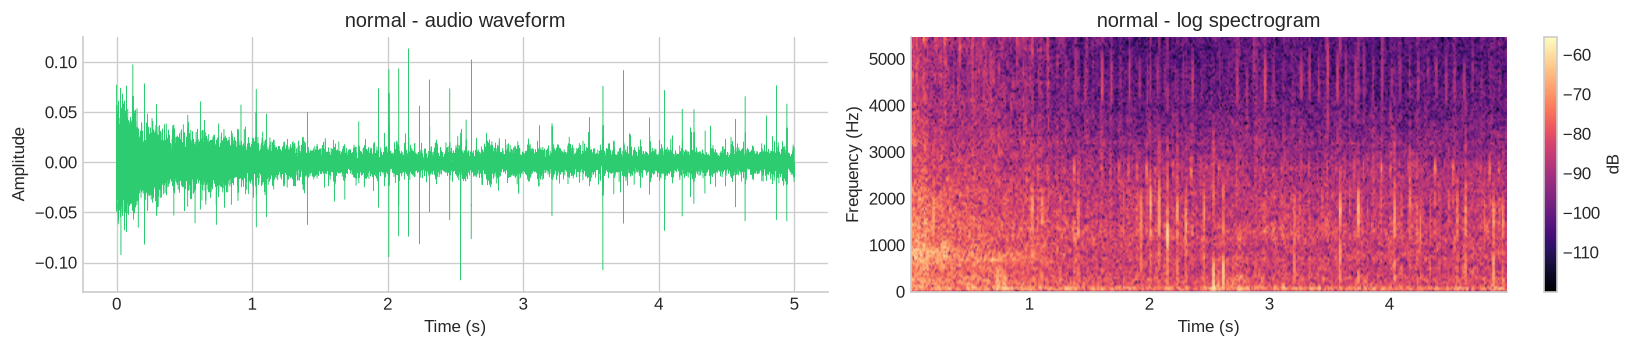

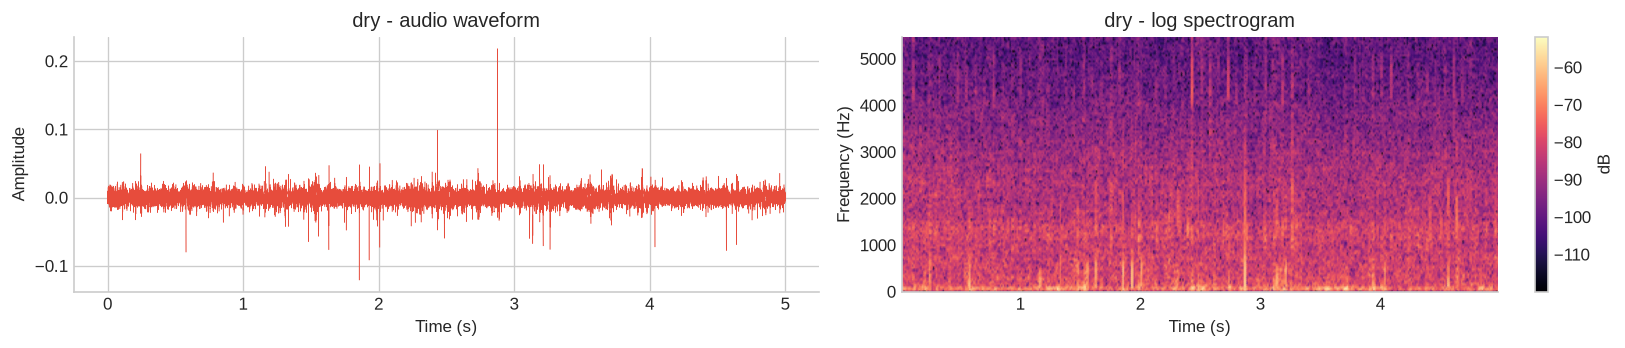

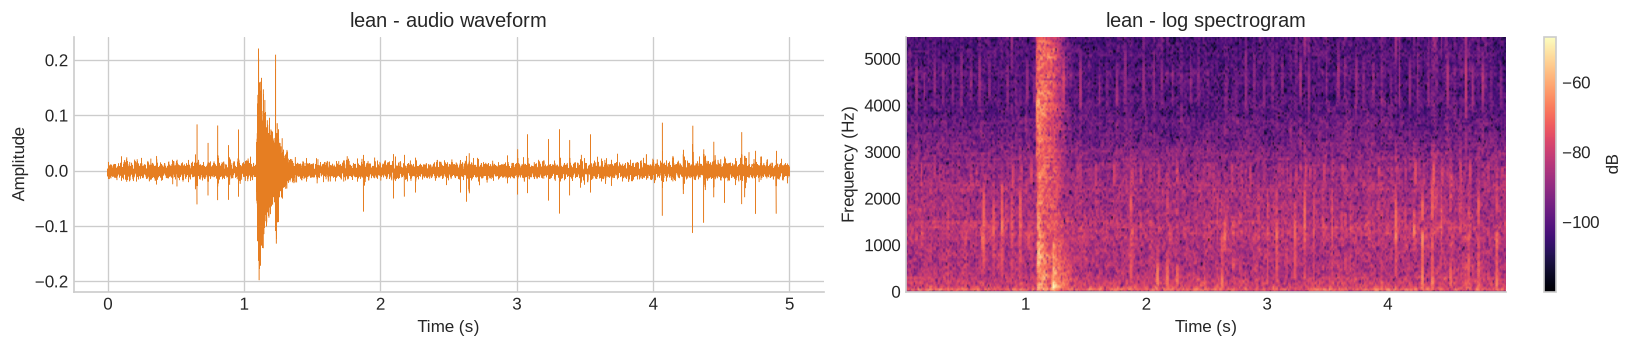

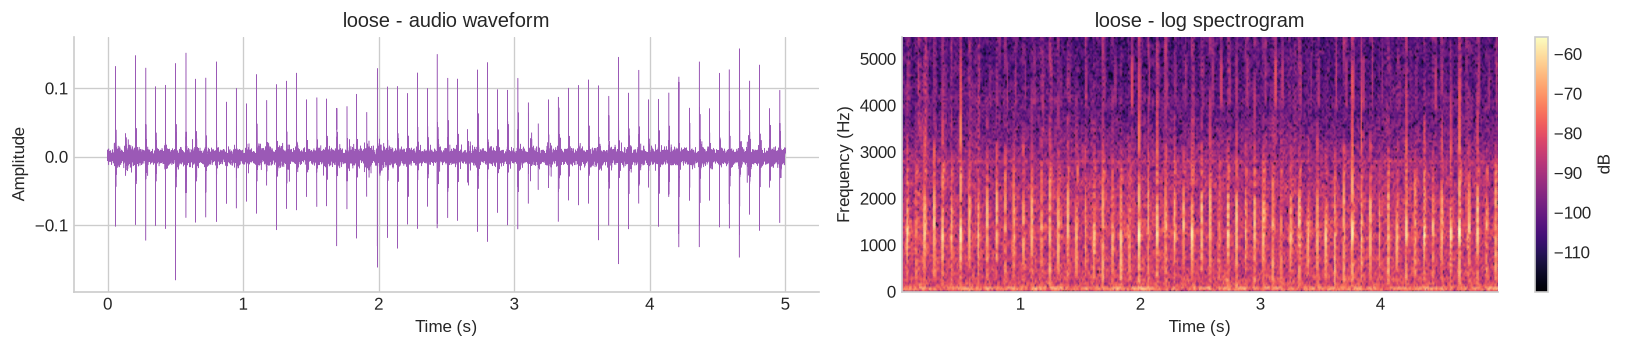

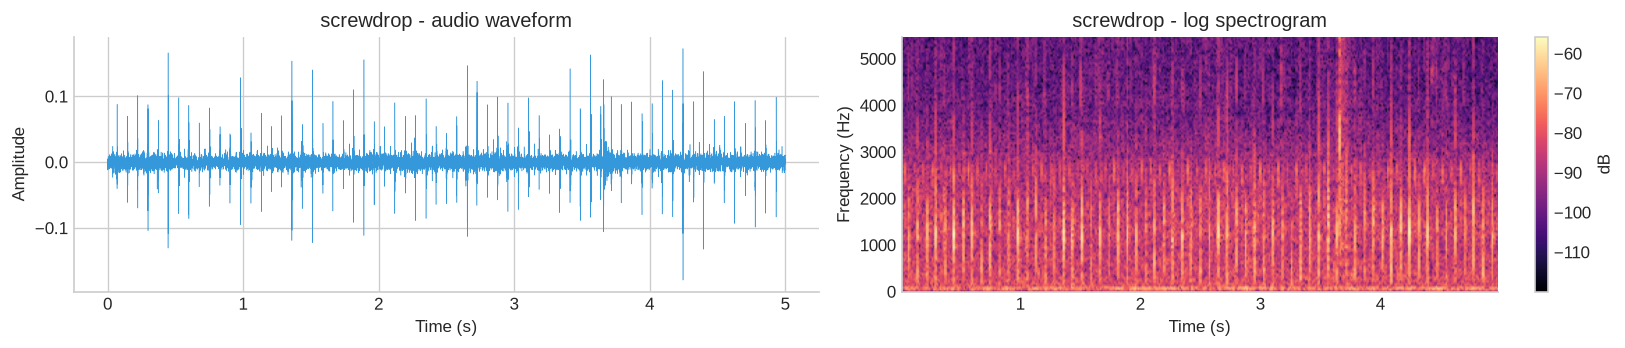

In [13]:
# ── Section 7-A: audio waveform + spectrogram ─────────────────────────────────

def plot_audio_eda(sample_id: str, fault: str) -> None:
    wav, sr = load_audio(sample_id)
    if not validate_audio(wav, sr, sample_id):
        return
    t = np.arange(len(wav)) / sr
    fig, axes = plt.subplots(1, 2, figsize=(14, 3))
    axes[0].plot(t, wav, lw=0.3, color=PALETTE.get(fault, "C0"))
    axes[0].set_xlabel("Time (s)"); axes[0].set_ylabel("Amplitude")
    axes[0].set_title(f"{fault} - audio waveform")

    # Log-scaled spectrogram
    f, t_spec, Sxx = ss.spectrogram(wav, fs=sr, nperseg=1024, noverlap=512)
    Sxx_db = 10 * np.log10(Sxx + 1e-12)
    im = axes[1].pcolormesh(t_spec, f[:len(f)//4], Sxx_db[:len(f)//4], shading="gouraud", cmap="magma")
    axes[1].set_xlabel("Time (s)"); axes[1].set_ylabel("Frequency (Hz)")
    axes[1].set_title(f"{fault} - log spectrogram")
    plt.colorbar(im, ax=axes[1], label="dB")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "eda" / f"audio_spectrogram_{fault}.png", bbox_inches="tight")
    plt.show()

for fault, sid in repr_samples.items():
    plot_audio_eda(sid, fault)

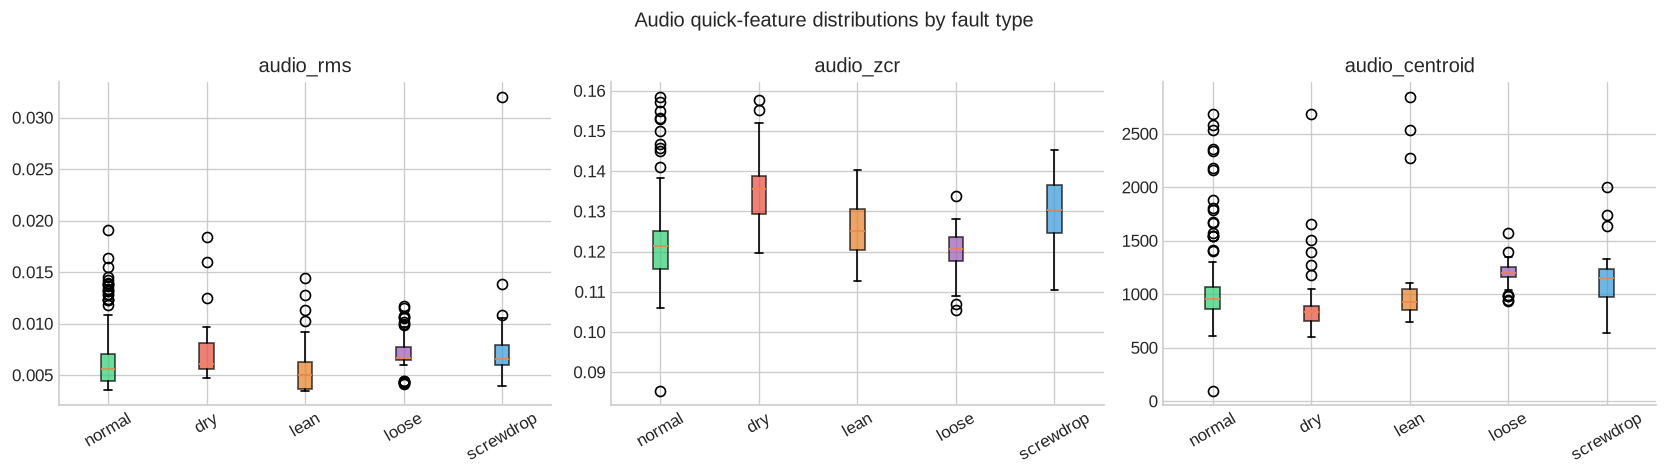

In [14]:
# ── Section 7-B: audio quick-feature distribution across classes ──────────────
# Pre-compute RMS and spectral centroid for all samples to compare classes.

quick_rows = []
for _, row in meta_df.iterrows():
    sid = row["sample_id"]
    try:
        wav, sr = load_audio(sid)
        rms = float(np.sqrt(np.mean(wav**2)))
        zcr = float(np.mean(np.abs(np.diff(np.sign(wav)))))
        f_w, pxx_w = ss.welch(wav, fs=sr, nperseg=2048)
        centroid = float(np.sum(f_w * pxx_w) / (np.sum(pxx_w) + 1e-12))
        quick_rows.append({"sample_id": sid, "fault": row["fault"],
                           "velocity": row.get("velocity"),
                           "audio_rms": rms, "audio_zcr": zcr, "audio_centroid": centroid})
    except Exception as exc:
        log.warning("Quick audio feature failed for %s: %s", sid, exc)

quick_df = pd.DataFrame(quick_rows)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, feat in zip(axes, ["audio_rms", "audio_zcr", "audio_centroid"]):
    for ft in FAULT_TYPES:
        vals = quick_df[quick_df["fault"] == ft][feat].dropna()
        ax.boxplot(vals, positions=[FAULT_TYPES.index(ft)],
                   patch_artist=True,
                   boxprops=dict(facecolor=PALETTE.get(ft, "grey"), alpha=0.7))
    ax.set_xticks(range(len(FAULT_TYPES)))
    ax.set_xticklabels(FAULT_TYPES, rotation=30)
    ax.set_title(feat)
plt.suptitle("Audio quick-feature distributions by fault type")
plt.tight_layout()
plt.savefig(OUT_DIR / "eda" / "audio_feature_distributions.png", bbox_inches="tight")
plt.show()

---
# 3. Synchronization Check


In [15]:
# ── Section 8: verify audio / vibration sample correspondence ─────────────────
# For representative samples: confirm that both modalities exist under the same
# sample_id, compare duration, and flag any mismatches.

sync_rows = []
for sid in list(repr_samples.values()) + list(meta_df["sample_id"].head(10)):
    rec = {"sample_id": sid}
    try:
        vib = load_vibration(sid)
        rec["vib_channels"] = vib.shape[0]
        rec["vib_samples"]  = vib.shape[1]
        rec["vib_duration_s"] = vib.shape[1] / VIB_STORED_HZ
    except Exception as e:
        rec["vib_channels"] = rec["vib_samples"] = rec["vib_duration_s"] = None
        rec["vib_error"] = str(e)
    try:
        wav, sr = load_audio(sid)
        rec["aud_sr"]       = sr
        rec["aud_samples"]  = len(wav)
        rec["aud_duration_s"] = len(wav) / sr
    except Exception as e:
        rec["aud_sr"] = rec["aud_samples"] = rec["aud_duration_s"] = None
        rec["aud_error"] = str(e)
    sync_rows.append(rec)

sync_df = pd.DataFrame(sync_rows)
print("Synchronization check (representative samples):")
print(sync_df[[c for c in ["sample_id","vib_duration_s","aud_duration_s","vib_channels","aud_sr"] if c in sync_df.columns]].to_string(index=False))

# Duration mismatch check (> 10% deviation)
if "vib_duration_s" in sync_df and "aud_duration_s" in sync_df:
    mismatches = sync_df[
        (sync_df["vib_duration_s"].notna()) &
        (sync_df["aud_duration_s"].notna()) &
        (abs(sync_df["vib_duration_s"] - sync_df["aud_duration_s"]) > 0.5)
    ]
    if len(mismatches):
        print(f"\n! Duration mismatches (>0.5s): {len(mismatches)} samples")
        print(mismatches[["sample_id","vib_duration_s","aud_duration_s"]].to_string())
    else:
        print("\n✓ No significant duration mismatches found.")

Synchronization check (representative samples):
                                            sample_id  vib_duration_s  aud_duration_s  vib_channels  aud_sr
                       normal__med_vel100_clean__0018            12.5             5.0             4   44100
            abnormal__dry__med_vel100_clean_dry__0025            12.5             5.0             4   44100
          abnormal__lean__med_vel100_clean_lean__0022            12.5             5.0             4   44100
        abnormal__loose__med_vel100_clean_loose__0037            12.5             5.0             4   44100
abnormal__screwdrop__med_vel100_clean_screwdrop__0033            12.5             5.0             4   44100
            abnormal__dry__med_vel100_clean_dry__0001            12.5             5.0             4   44100
            abnormal__dry__med_vel100_clean_dry__0009            12.5             5.0             4   44100
            abnormal__dry__med_vel100_clean_dry__0017            12.5             5.0   

---
# 4. ACF / PACF Analysis

We compute ACF and PACF **only** on condition-specific, source-index-ordered sequences of scalar features. This is statistically meaningful only when:

1. The source index provides a valid temporal ordering within the condition.
2. The condition-specific sequence has ≥ 30 observations (standard rule of thumb).
3. The selected samples are approximately evenly spaced.

> **Important:** Autocorrelation in these sequences reflects the persistence of machine operating state, not evidence of degradation.
> Because the compact dataset uses selected (sparse) indices, ACF estimates have limited statistical power and must be interpreted cautiously.

In [16]:
# ── Section 9-A: compute per-condition scalar feature sequences ────────────────
# We need the RMS and kurtosis for each sample before we can run ACF.
# This is a quick single-channel estimate (Ch 1 only) purely for ACF analysis.

acf_rows = []
for _, row in meta_df.iterrows():
    sid = row["sample_id"]
    try:
        vib = load_vibration(sid)
        if not validate_vib(vib, sid):
            continue
        ch0 = vib[0]
        acf_rows.append({
            "sample_id":    sid,
            "fault":        row["fault"],
            "velocity":     row.get("velocity"),
            "source_index": row.get("source_index"),
            "vib_rms":      float(np.sqrt(np.mean(ch0**2))),
            "vib_kurtosis": float(st.kurtosis(ch0)),
            "vib_crest":    float(np.max(np.abs(ch0)) / (np.sqrt(np.mean(ch0**2)) + 1e-12)),
        })
    except Exception as exc:
        log.warning("ACF prep failed %s: %s", sid, exc)

acf_df = pd.DataFrame(acf_rows)
print(f"ACF prep complete: {len(acf_df)} samples")

ACF prep complete: 288 samples


[SKIP ACF] dry_v60: only 18 observations (need ≥ 20)
[SKIP ACF] dry_v60: only 18 observations (need ≥ 20)
[SKIP ACF] dry_v80: only 9 observations (need ≥ 20)
[SKIP ACF] dry_v80: only 9 observations (need ≥ 20)
[SKIP ACF] dry_v100: only 9 observations (need ≥ 20)
[SKIP ACF] dry_v100: only 9 observations (need ≥ 20)
[SKIP ACF] lean_v60: only 18 observations (need ≥ 20)
[SKIP ACF] lean_v60: only 18 observations (need ≥ 20)
[SKIP ACF] lean_v80: only 9 observations (need ≥ 20)
[SKIP ACF] lean_v80: only 9 observations (need ≥ 20)
[SKIP ACF] lean_v100: only 9 observations (need ≥ 20)
[SKIP ACF] lean_v100: only 9 observations (need ≥ 20)
[SKIP ACF] loose_v60: only 9 observations (need ≥ 20)
[SKIP ACF] loose_v60: only 9 observations (need ≥ 20)
[SKIP ACF] loose_v80: only 18 observations (need ≥ 20)
[SKIP ACF] loose_v80: only 18 observations (need ≥ 20)
[SKIP ACF] loose_v100: only 9 observations (need ≥ 20)
[SKIP ACF] loose_v100: only 9 observations (need ≥ 20)


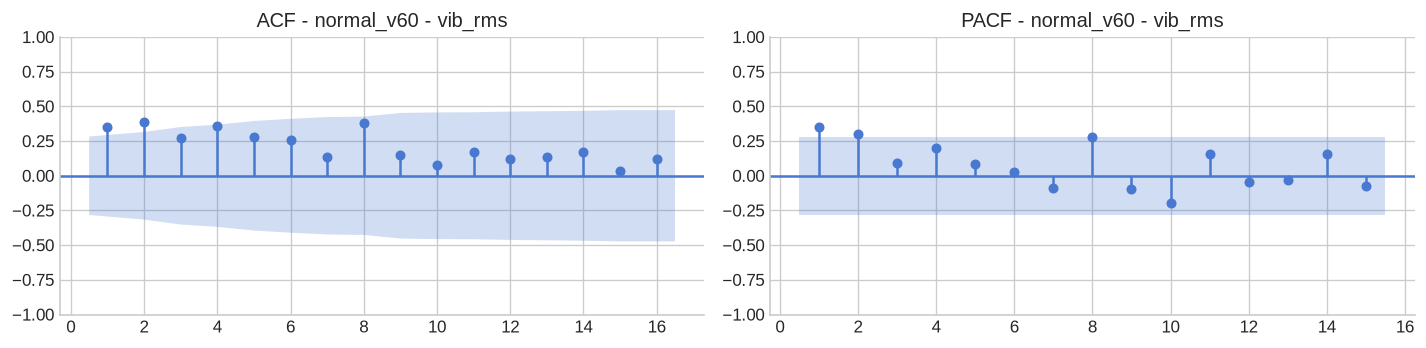

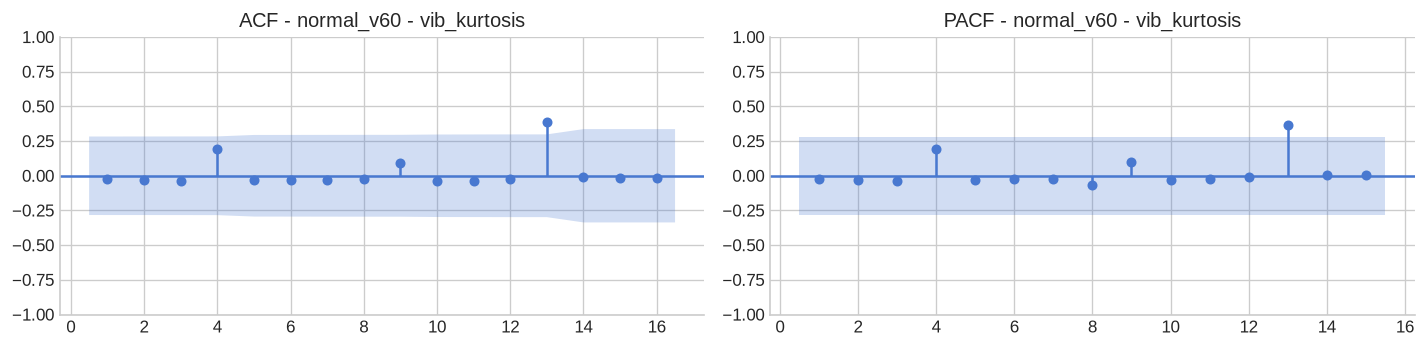

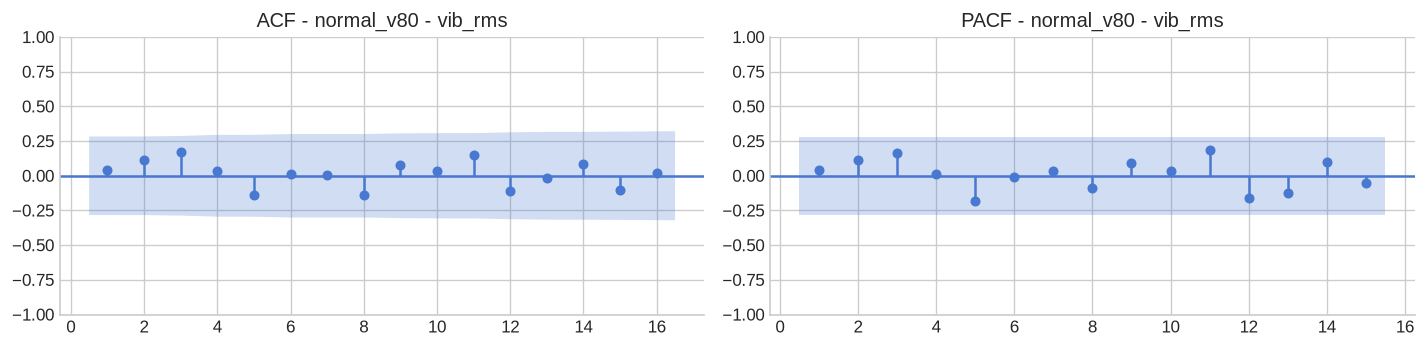

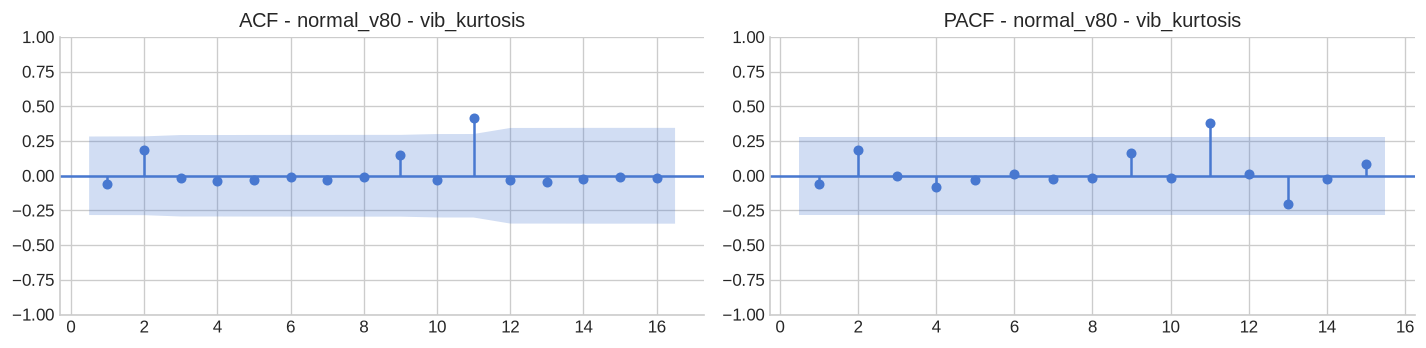

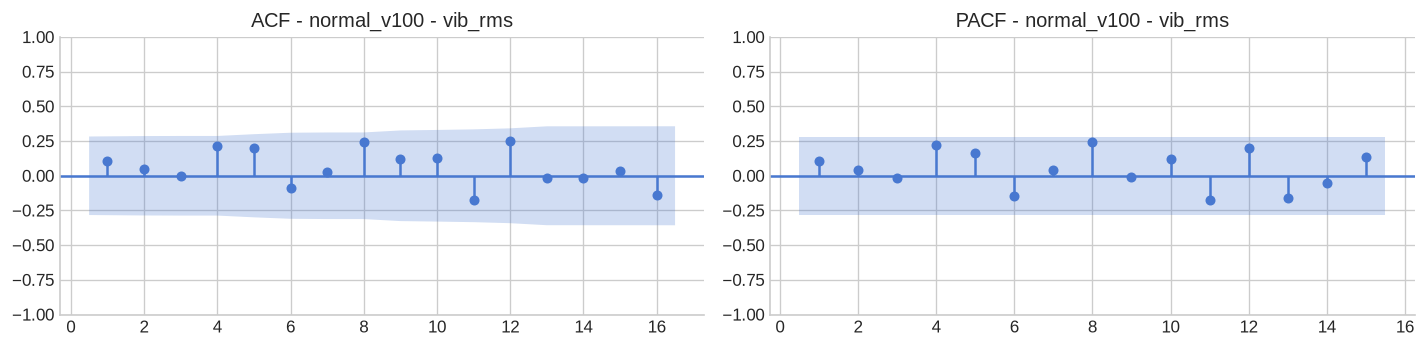

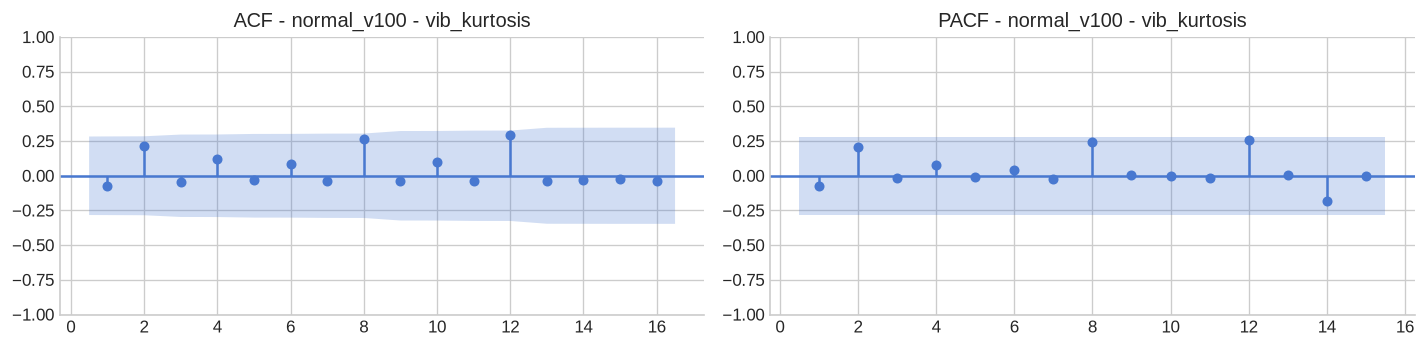

[SKIP ACF] screwdrop_v60: only 9 observations (need ≥ 20)
[SKIP ACF] screwdrop_v60: only 9 observations (need ≥ 20)
[SKIP ACF] screwdrop_v80: only 18 observations (need ≥ 20)
[SKIP ACF] screwdrop_v80: only 18 observations (need ≥ 20)
[SKIP ACF] screwdrop_v100: only 9 observations (need ≥ 20)
[SKIP ACF] screwdrop_v100: only 9 observations (need ≥ 20)


In [17]:
# ── Section 9-B: ACF / PACF for conditions with enough observations ────────────

MIN_ACF_SAMPLES = 20

def run_acf_pacf(series: pd.Series, title: str, feature: str, out_stem: str) -> None:
    if len(series) < MIN_ACF_SAMPLES:
        print(f"[SKIP ACF] {title}: only {len(series)} observations (need ≥ {MIN_ACF_SAMPLES})")
        return
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))
    plot_acf(series.values, lags=min(len(series)//3, 20), ax=axes[0], zero=False)
    axes[0].set_title(f"ACF - {title} - {feature}")
    plot_pacf(series.values, lags=min(len(series)//3 - 1, 20), ax=axes[1], zero=False, method="ywm")
    axes[1].set_title(f"PACF - {title} - {feature}")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "eda" / f"acf_{out_stem}.png", bbox_inches="tight")
    plt.show()

if "source_index" in acf_df.columns and acf_df["source_index"].notna().any():
    for (fault, velocity), grp in acf_df.groupby(["fault", "velocity"]):
        grp_sorted = grp.sort_values("source_index")
        for feat in ["vib_rms", "vib_kurtosis"]:
            run_acf_pacf(
                grp_sorted[feat].dropna(),
                title=f"{fault}_v{int(velocity)}",
                feature=feat,
                out_stem=f"{fault}_v{int(velocity)}_{feat}",
            )
else:
    print("[INFO] No temporal ordering available - ACF/PACF skipped.")
    print("ACF/PACF requires source_index to establish clip ordering within a condition.")

---
# 5. Vibration Feature Extraction

We extract features in 1-second sliding windows (50% overlap), then aggregate to clip level. This gives a manageable feature matrix even for a small dataset, while preserving intra-clip signal variation as statistical descriptors.

**Why clip-level aggregation?** With ~288 samples, using raw windows would create ~2880 pseudo-samples from 9 windows × 288 clips. This inflates the dataset artificially and introduces within-clip leakage if not handled carefully. Clip-level features are the primary representation for the classifier. Window-level sequences are retained for temporal smoothing experiments.

In [18]:
# ── Section 10-A: vibration window-level feature extractor ────────────────────

def _band_power(f: np.ndarray, pxx: np.ndarray, lo: float, hi: float) -> float:
    mask = (f >= lo) & (f < hi)
    return float(np.trapezoid(pxx[mask], f[mask]))


def extract_vib_window_features(seg: np.ndarray, fs: int, ch_idx: int) -> dict:
    """Extract time, frequency, and envelope features for one channel window.
    
    Args:
        seg: 1D float32 array, one channel one window
        fs:  sampling rate in Hz
        ch_idx: channel index (0-based) for feature name prefix
    """
    p = f"vib_ch{ch_idx+1}_"
    feats: dict = {}

    # ── Time domain ──
    rms   = float(np.sqrt(np.mean(seg**2)))
    peak  = float(np.max(np.abs(seg)))
    feats[p + "mean"]        = float(np.mean(seg))
    feats[p + "std"]         = float(np.std(seg))
    feats[p + "var"]         = float(np.var(seg))
    feats[p + "min"]         = float(np.min(seg))
    feats[p + "max"]         = float(np.max(seg))
    feats[p + "peak2peak"]   = float(np.ptp(seg))
    feats[p + "rms"]         = rms
    feats[p + "skewness"]    = float(st.skew(seg))
    feats[p + "kurtosis"]    = float(st.kurtosis(seg))
    feats[p + "crest"]       = peak / (rms + 1e-12)
    feats[p + "impulse"]     = peak / (np.mean(np.abs(seg)) + 1e-12)
    feats[p + "shape"]       = rms / (np.mean(np.abs(seg)) + 1e-12)

    # ── Frequency domain (Welch) ──
    nperseg = min(512, len(seg))
    f_ax, pxx = ss.welch(seg, fs=fs, nperseg=nperseg)
    total_pwr = float(np.sum(pxx)) + 1e-12
    dom_idx = int(np.argmax(pxx))
    feats[p + "dom_freq"]     = float(f_ax[dom_idx])
    feats[p + "dom_power"]    = float(pxx[dom_idx])
    feats[p + "spec_centroid"]= float(np.sum(f_ax * pxx) / total_pwr)
    feats[p + "spec_bw"]      = float(np.sqrt(np.sum((f_ax - feats[p+"spec_centroid"])**2 * pxx) / total_pwr))
    # Spectral entropy
    pnorm = pxx / total_pwr
    feats[p + "spec_entropy"] = float(-np.sum(pnorm * np.log(pnorm + 1e-12)))
    feats[p + "total_pwr"]    = float(total_pwr)

    for band_name, (lo, hi) in VIB_BANDS.items():
        bp = _band_power(f_ax, pxx, lo, hi)
        feats[p + f"band_{band_name}"] = bp
        feats[p + f"relband_{band_name}"] = bp / total_pwr
    if VIB_BANDS.get("low") and VIB_BANDS.get("high"):
        lo_bp  = feats.get(p + "band_low", 0)
        hi_bp  = feats.get(p + "band_high", 0)
        feats[p + "hi_lo_ratio"] = hi_bp / (lo_bp + 1e-12)

    # ── Envelope ──
    env = _envelope(seg, fs)
    env_rms = float(np.sqrt(np.mean(env**2)))
    feats[p + "env_rms"]    = env_rms
    feats[p + "env_var"]    = float(np.var(env))
    feats[p + "env_kurt"]   = float(st.kurtosis(env))
    feats[p + "env_peak"]   = float(np.max(env))
    f_env, pxx_env = ss.welch(env, fs=fs, nperseg=nperseg)
    tot_ep = float(np.sum(pxx_env)) + 1e-12
    feats[p + "env_spec_centroid"] = float(np.sum(f_env * pxx_env) / tot_ep)
    feats[p + "env_dom_freq"]      = float(f_env[np.argmax(pxx_env)])
    for band_name, (lo, hi) in VIB_BANDS.items():
        feats[p + f"env_band_{band_name}"] = _band_power(f_env, pxx_env, lo, hi)

    return feats


def extract_vib_cross_channel_features(vib: np.ndarray) -> dict:
    """Cross-channel Pearson correlations and RMS ratios."""
    n_ch = vib.shape[0]
    feats: dict = {}
    rms_vals = [float(np.sqrt(np.mean(vib[ch]**2))) for ch in range(n_ch)]
    for i in range(n_ch):
        for j in range(i+1, n_ch):
            r, _ = st.pearsonr(vib[i], vib[j])
            feats[f"vib_corr_ch{i+1}_ch{j+1}"] = float(r)
            feats[f"vib_rms_ratio_ch{i+1}_ch{j+1}"] = rms_vals[i] / (rms_vals[j] + 1e-12)
    return feats


print("Vibration feature extractors defined.")

Vibration feature extractors defined.


In [19]:
# ── Section 10-B: extract vibration features for all samples ──────────────────

win_samples = int(WINDOW_SIZE_S * VIB_STORED_HZ)
hop_samples = int(HOP_SIZE_S * VIB_STORED_HZ)

vib_window_rows: List[dict] = []
vib_clip_rows:   List[dict] = []

for _, meta_row in meta_df.iterrows():
    sid = meta_row["sample_id"]
    try:
        vib = load_vibration(sid)
    except Exception as exc:
        log.error("load_vibration failed %s: %s", sid, exc)
        audit_df.loc[audit_df["sample_id"] == sid, "status"] = "vib_load_error"
        audit_df.loc[audit_df["sample_id"] == sid, "reason"] = str(exc)
        continue

    if not validate_vib(vib, sid):
        audit_df.loc[audit_df["sample_id"] == sid, "status"] = "vib_invalid"
        continue

    n_ch = vib.shape[0]
    T    = vib.shape[1]

    # Sliding windows - do not leak across clips
    starts = list(range(0, T - win_samples + 1, hop_samples))
    window_feats_list = []
    for w_idx, start in enumerate(starts):
        seg_all = vib[:, start:start + win_samples]
        w_feats: dict = {
            "sample_id":    sid,
            "fault":        meta_row["fault"],
            "is_fault":     int(meta_row["is_fault"]),
            "velocity":     meta_row.get("velocity"),
            "source_index": meta_row.get("source_index"),
            "window_idx":   w_idx,
            "win_start_s":  start / VIB_STORED_HZ,
            "win_end_s":    (start + win_samples) / VIB_STORED_HZ,
        }
        for ch in range(n_ch):
            ch_feats = extract_vib_window_features(seg_all[ch], VIB_STORED_HZ, ch)
            w_feats.update(ch_feats)
        # Cross-channel on the full window
        w_feats.update(extract_vib_cross_channel_features(seg_all))
        window_feats_list.append(w_feats)
        vib_window_rows.append(w_feats)

    # Clip-level: aggregate window features with mean / std / min / max / median
    if window_feats_list:
        tmp = pd.DataFrame(window_feats_list)
        num_cols = tmp.select_dtypes(include=[np.number]).columns.tolist()
        exclude = {"window_idx", "win_start_s", "win_end_s", "is_fault", "velocity", "source_index"}
        feat_cols = [c for c in num_cols if c not in exclude]
        clip_feats: dict = {
            "sample_id":    sid,
            "fault":        meta_row["fault"],
            "is_fault":     int(meta_row["is_fault"]),
            "velocity":     meta_row.get("velocity"),
            "source_index": meta_row.get("source_index"),
        }
        for fc in feat_cols:
            v = tmp[fc].values
            clip_feats[fc + "_mean"]   = float(np.nanmean(v))
            clip_feats[fc + "_std"]    = float(np.nanstd(v))
            clip_feats[fc + "_min"]    = float(np.nanmin(v))
            clip_feats[fc + "_max"]    = float(np.nanmax(v))
            clip_feats[fc + "_median"] = float(np.nanmedian(v))
            clip_feats[fc + "_p90"]    = float(np.nanpercentile(v, 90))
        vib_clip_rows.append(clip_feats)

vib_win_df  = pd.DataFrame(vib_window_rows)
vib_clip_df = pd.DataFrame(vib_clip_rows)

print(f"Vibration windows : {len(vib_win_df)} rows, {len(vib_win_df.columns)} cols")
print(f"Vibration clips   : {len(vib_clip_df)} rows, {len(vib_clip_df.columns)} cols")

vib_win_df.to_parquet(OUT_DIR / "features" / "vibration_window_features.parquet", index=False)
vib_clip_df.to_parquet(OUT_DIR / "features" / "vibration_features.parquet", index=False)
print("Saved to outputs/features/vibration_features.parquet")

Vibration windows : 6912 rows, 156 cols
Vibration clips   : 288 rows, 893 cols
Saved to outputs/features/vibration_features.parquet


---
# 6. Audio Feature Extraction

We use `librosa` for MFCC computation - a pure signal-processing library with no neural network dependency. The mel-filterbank DCT approach is significantly more robust than a hand-rolled implementation.

In [20]:
# ── Section 11-A: audio window feature extractor ──────────────────────────────

def extract_audio_window_features(seg: np.ndarray, sr: int) -> dict:
    """Extract spectral and MFCC features for one audio window."""
    feats: dict = {}

    # ── Time domain ──
    rms  = float(np.sqrt(np.mean(seg**2)))
    peak = float(np.max(np.abs(seg)))
    feats["aud_rms"]        = rms
    feats["aud_var"]        = float(np.var(seg))
    feats["aud_peak"]       = peak
    feats["aud_peak2peak"]  = float(np.ptp(seg))
    feats["aud_zcr"]        = float(np.mean(librosa.feature.zero_crossing_rate(seg)[0]))
    feats["aud_crest"]      = peak / (rms + 1e-12)

    # ── Spectral ──
    S = np.abs(librosa.stft(seg, n_fft=2048, hop_length=512))**2
    f_hz = librosa.fft_frequencies(sr=sr, n_fft=2048)

    # Welch PSD for band features (matches vibration approach)
    f_w, pxx_w = ss.welch(seg, fs=sr, nperseg=min(2048, len(seg)))
    total_pwr_w = float(np.sum(pxx_w)) + 1e-12

    feats["aud_spec_centroid"]  = float(librosa.feature.spectral_centroid(S=S, sr=sr).mean())
    feats["aud_spec_bw"]        = float(librosa.feature.spectral_bandwidth(S=S, sr=sr).mean())
    feats["aud_spec_rolloff"]   = float(librosa.feature.spectral_rolloff(S=S, sr=sr, roll_percent=0.85).mean())
    # Spectral entropy from Welch
    pnorm = pxx_w / total_pwr_w
    feats["aud_spec_entropy"]   = float(-np.sum(pnorm * np.log(pnorm + 1e-12)))
    feats["aud_dom_freq"]       = float(f_w[np.argmax(pxx_w)])
    feats["aud_total_pwr"]      = float(total_pwr_w)

    for band_name, (lo, hi) in AUD_BANDS.items():
        bp = _band_power(f_w, pxx_w, lo, hi)
        feats[f"aud_band_{band_name}"] = bp
        feats[f"aud_relband_{band_name}"] = bp / total_pwr_w

    # ── MFCC ──
    mfccs = librosa.feature.mfcc(y=seg, sr=sr, n_mfcc=N_MFCC, n_fft=2048, hop_length=512)
    for i in range(N_MFCC):
        feats[f"aud_mfcc{i+1}_mean"] = float(mfccs[i].mean())
        feats[f"aud_mfcc{i+1}_std"]  = float(mfccs[i].std())
        feats[f"aud_mfcc{i+1}_min"]  = float(mfccs[i].min())
        feats[f"aud_mfcc{i+1}_max"]  = float(mfccs[i].max())

    # Delta MFCC
    delta = librosa.feature.delta(mfccs)
    for i in range(N_MFCC):
        feats[f"aud_dmfcc{i+1}_mean"] = float(delta[i].mean())
        feats[f"aud_dmfcc{i+1}_std"]  = float(delta[i].std())

    return feats


print("Audio feature extractor defined.")

Audio feature extractor defined.


In [21]:
# ── Section 11-B: extract audio features for all samples ─────────────────────

aud_window_rows: List[dict] = []
aud_clip_rows:   List[dict] = []

for _, meta_row in meta_df.iterrows():
    sid = meta_row["sample_id"]
    try:
        wav, sr = load_audio(sid)
    except Exception as exc:
        log.error("load_audio failed %s: %s", sid, exc)
        audit_df.loc[audit_df["sample_id"] == sid, "status"] = "aud_load_error"
        audit_df.loc[audit_df["sample_id"] == sid, "reason"] = str(exc)
        continue

    if not validate_audio(wav, sr, sid):
        audit_df.loc[audit_df["sample_id"] == sid, "status"] = "aud_invalid"
        continue

    win_s = int(WINDOW_SIZE_S * sr)
    hop_s = int(HOP_SIZE_S * sr)
    starts = list(range(0, len(wav) - win_s + 1, hop_s))
    window_feats_list = []

    for w_idx, start in enumerate(starts):
        seg = wav[start:start + win_s]
        w_feats: dict = {
            "sample_id":    sid,
            "fault":        meta_row["fault"],
            "is_fault":     int(meta_row["is_fault"]),
            "velocity":     meta_row.get("velocity"),
            "source_index": meta_row.get("source_index"),
            "window_idx":   w_idx,
        }
        w_feats.update(extract_audio_window_features(seg, sr))
        window_feats_list.append(w_feats)
        aud_window_rows.append(w_feats)

    if window_feats_list:
        tmp = pd.DataFrame(window_feats_list)
        feat_cols = [c for c in tmp.select_dtypes(include=[np.number]).columns
                     if c not in {"window_idx", "is_fault", "velocity", "source_index"}]
        clip_feats: dict = {
            "sample_id":    sid,
            "fault":        meta_row["fault"],
            "is_fault":     int(meta_row["is_fault"]),
            "velocity":     meta_row.get("velocity"),
            "source_index": meta_row.get("source_index"),
        }
        for fc in feat_cols:
            v = tmp[fc].values
            clip_feats[fc + "_mean"]   = float(np.nanmean(v))
            clip_feats[fc + "_std"]    = float(np.nanstd(v))
            clip_feats[fc + "_min"]    = float(np.nanmin(v))
            clip_feats[fc + "_max"]    = float(np.nanmax(v))
            clip_feats[fc + "_median"] = float(np.nanmedian(v))
            clip_feats[fc + "_p90"]    = float(np.nanpercentile(v, 90))
        aud_clip_rows.append(clip_feats)

aud_win_df  = pd.DataFrame(aud_window_rows)
aud_clip_df = pd.DataFrame(aud_clip_rows)

print(f"Audio windows : {len(aud_win_df)} rows, {len(aud_win_df.columns)} cols")
print(f"Audio clips   : {len(aud_clip_df)} rows, {len(aud_clip_df.columns)} cols")

aud_win_df.to_parquet(OUT_DIR / "features" / "audio_window_features.parquet", index=False)
aud_clip_df.to_parquet(OUT_DIR / "features" / "audio_features.parquet", index=False)
print("Saved to outputs/features/audio_features.parquet")

Audio windows : 2592 rows, 106 cols
Audio clips   : 288 rows, 605 cols
Saved to outputs/features/audio_features.parquet


In [22]:
# ── Section 11-C: save processing audit ──────────────────────────────────────
audit_df.to_parquet(OUT_DIR / "features" / "processing_audit.parquet", index=False)
print("Processing audit:")
print(audit_df["status"].value_counts().to_string())
failed = audit_df[audit_df["status"] != "ok"]
if len(failed):
    print(f"\nFailed samples ({len(failed)}):")
    print(failed.to_string(index=False))

Processing audit:
status
ok    288


In [23]:
# Save features to disk
vib_clip_df.to_parquet(OUT_DIR / 'features' / '03_vib_clip.parquet', index=False)
aud_clip_df.to_parquet(OUT_DIR / 'features' / '03_aud_clip.parquet', index=False)
vib_win_df.to_parquet(OUT_DIR / 'features' / '03_vib_win.parquet', index=False)
aud_win_df.to_parquet(OUT_DIR / 'features' / '03_aud_win.parquet', index=False)
print('Feature extraction complete. Dataframes saved.')


Feature extraction complete. Dataframes saved.
